In [40]:
import pandas as pd
import numpy as np 

import seaborn as sns
import matplotlib.pyplot as plt 

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier
from scipy.stats import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


In [22]:
df=pd.read_csv("Titanic.csv", usecols=['Age','Fare','Survived'])


In [24]:
df['Age'].fillna(df['Age'].mean())
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [25]:
x=df.iloc[:,1:3]
y=df.iloc[:,0]
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
x_train.head()


,Age,Fare
29,30.003333,28.91
535,23.000000,30.60
695,1.300000,46.66
557,14.200000,4.27
836,13.200000,40.74


In [51]:
trf1 = ColumnTransformer([
    ('functiontransformer', FunctionTransformer(func=np.log),['Fare'])
],remainder = 'passthrough')

In [59]:
x_train_transformed = trf1.fit_transform(x_train)
x_test_transformed = trf1.transform(x_test)

C:\Users\essas\AppData\Local\Temp\ipykernel_5336\2558297270.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train_transformed)


<Axes: ylabel='Density'>

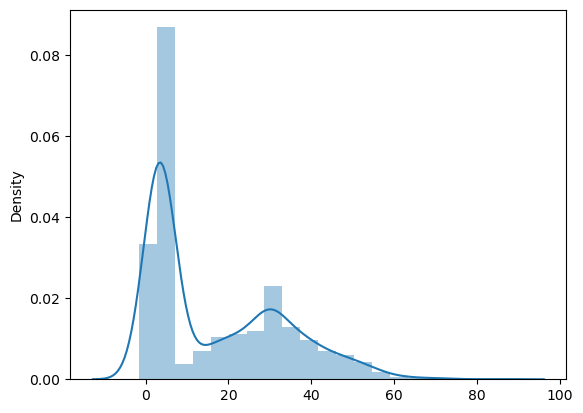

In [60]:
sns.distplot(x_train_transformed)

In [118]:
clf= LogisticRegression()
clf.fit(x_train_transformed,y_train)
y_pred=clf.predict(x_test_transformed)
accuracy = accuracy_score(y_test,y_pred)
accuracy

0.665